In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

In [ ]:
df=pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f"Loaded:{df.shape[0]} rows,{df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['match_label'].value_counts)
df.head(3)

Loaded:19 rows,39 columns
Columns:['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'match_label', 'match_label_lower', 'resume_len', 'jd_len']

Label distribution:
<bound method IndexOpsMixin.value_counts of 0     medium match
1     medium match
2       high match
3     medium match
4       high match
5     

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,match_label,match_label_lower,resume_len,jd_len
0,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.75,medium match,medium match,43,43
1,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.65,medium match,medium match,30,30
2,NaN,"To secure an IT specialist, desktop support, n...","['Microsoft Applications', 'Network Security',...","['Glen Oaks High School', 'Glen Oaks High Scho...","['Bachelor Degree', 'Associate Degree']","[None, None]","[None, None]","[None, None]",['Electronics and Communications Engineering T...,"['N/A', 'Company Name', 'Company Name']",...,Bachelors or Masters degree in Computer Scienc...,NaN,NaN,Machine Learning Design\nData Analysis\nModel ...,Python\nR or Java\nTensorFlow\nPyTorch\nScikit...,0.85,high match,high match,20,20


In [ ]:
print('loading the bert model')
model=SentenceTransformer('all-mpnet-base-v2')
print("Model loaded!")
print(f"Model:all-mpnet-base-v2")
print(f"Parameters:22.7M")
print(f"Embed dims:768")
print(f"Max tokens:{model.max_seq_length}")

loading the bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
Model:all-mpnet-base-v2
Parameters:22.7M
Embed dims:768
Max tokens:384


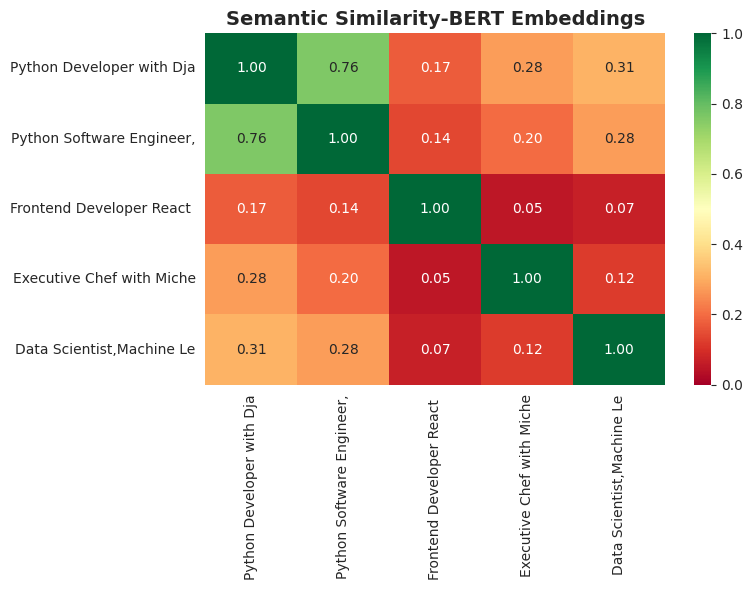

In [ ]:
texts=[
    "Python Developer with Django experience",
    "Python Software Engineer,Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist,Machine Learning,PyTorch",
]

embeddings=model.encode(texts)
sim_matrix=cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix,annot=True,fmt='.2f',cmap='RdYlGn',
            xticklabels=[t[:25] for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin=0,vmax=1)
plt.title('Semantic Similarity-BERT Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Generating resume embeddings...")
resume_embeddings=model.encode(
    df['career_objective'].fillna('').tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True

)

print("\nGenerating job description embeddings...")
jd_embeddings=model.encode(
    df['skills_required'].fillna('').tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape:{resume_embeddings.shape}")
print(f"JD embeddings shape:{jd_embeddings.shape}")
print(f"Each text -> {resume_embeddings.shape[1]}-dimensional vector")

Generating resume embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Resume embeddings shape:(19, 768)
JD embeddings shape:(19, 768)
Each text -> 768-dimensional vector


In [ ]:
pair_similarities=[]
for i in range(len(resume_embeddings)):
  sim=cosine_similarity([resume_embeddings[i]],[jd_embeddings[i]])[0][0]
  pair_similarities.append(sim)

df['bert_similarity']=pair_similarities

print("Cosine similarity computed for all pairs.")
print(df[['match_label','matched_score','bert_similarity']].head(10))

Cosine similarity computed for all pairs.
    match_label  matched_score  bert_similarity
0  medium match       0.750000         0.033920
1  medium match       0.650000         0.119110
2    high match       0.850000         0.056926
3  medium match       0.650000         0.070006
4    high match       0.850000        -0.033793
5    high match       0.850000        -0.042837
6     low match       0.333333         0.119538
7  medium match       0.650000         1.000000
8    high match       0.850000         0.247973
9    high match       0.850000         0.106609


In [ ]:
mae=mean_absolute_error(df['matched_score'],df['bert_similarity'])
rmse=np.sqrt(mean_squared_error(df['matched_score'],df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning)")
print("="*50)
print(f"MAE:{mae:.4f}) (lower is better)")
print(f"RMSE:{rmse:.4f}(lower is better)")

Base BERT Model Performance (before fine-tuning)
MAE:0.5930) (lower is better)
RMSE:0.6365(lower is better)


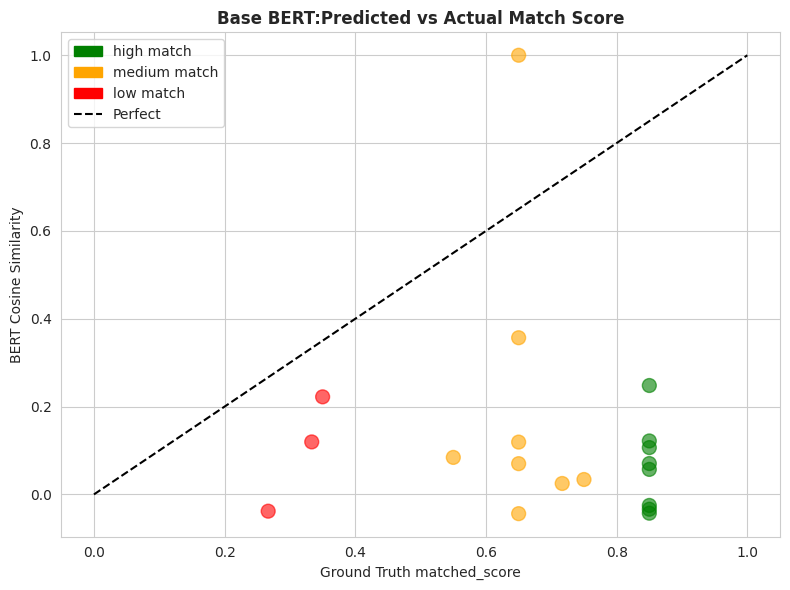

In [ ]:
plt.figure(figsize=(8,6))
colors=df['match_label'].map({'low match':'red','medium match':'orange','high match':'green'})
plt.scatter(df['matched_score'],df['bert_similarity'],c=colors,alpha=0.6, marker='o', s=100) # Increased marker size (s=100)
plt.plot([0,1],[0,1],'k--',label='Perfect prediction')
plt.xlabel('Ground Truth matched_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT:Predicted vs Actual Match Score', fontweight='bold')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green',label='high match'),
    Patch(color='orange',label='medium match'),
    Patch(color='red',label='low match'),
    plt.Line2D([0],[0],color='black',linestyle='--',label='Perfect')
])

plt.tight_layout()
plt.show()

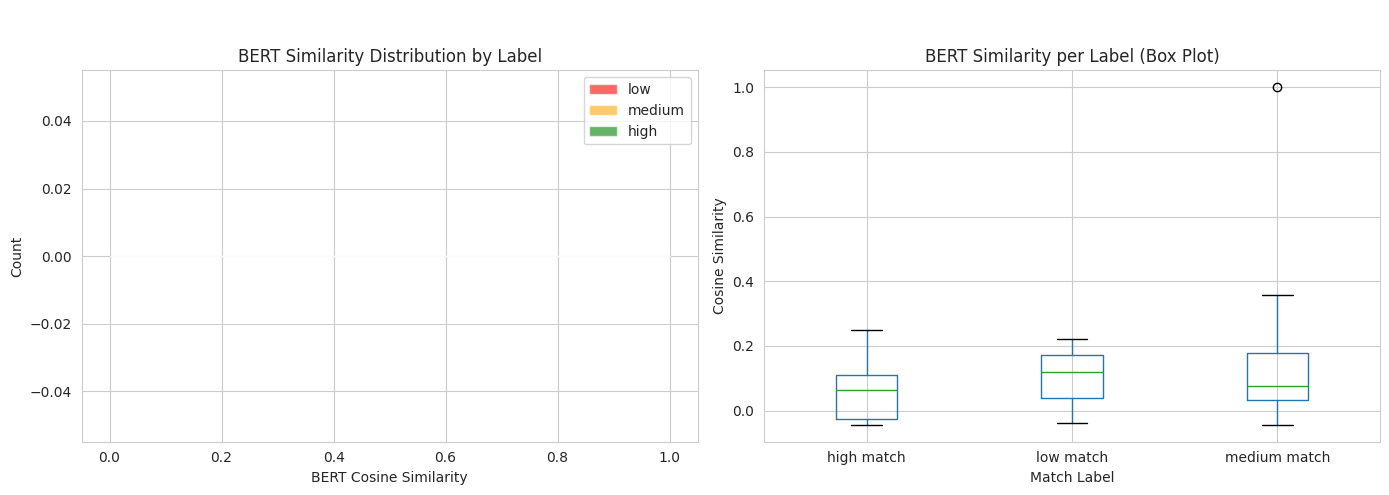


 Overlap between labels = base model struggles to separate high vs low matches
Goal of fine-tuning:push these distributions apart


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

for label,color in [('low','red'),('medium','orange'),('high','green')]:
  subset=df[df['match_label']==label]['bert_similarity']
  axes[0].hist(subset,bins=20,alpha=0.6,label=label,color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

df.boxplot(column='bert_similarity',by='match_label',positions=[0,1,2],ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')
plt.suptitle(' ')

plt.tight_layout()
plt.show()

print("\n Overlap between labels = base model struggles to separate high vs low matches")
print("Goal of fine-tuning:push these distributions apart")

In [ ]:
df['resume_text'] = (
    df['career_objective'].fillna('') + ' ' +
    df['skills'].fillna('') + ' ' +
    df['degree_names'].fillna('') + ' ' +
    df['professional_company_names'].fillna('') + ' ' +
    df['responsibilities'].fillna('')
)

In [ ]:
df['job_description'] = (
    df['﻿job_position_name'].fillna('') + ' ' +
    df['educationaL_requirements'].fillna('') + ' ' +
    df['experiencere_requirement'].fillna('') + ' ' +
    df['skills_required'].fillna('') + ' ' +
    df['responsibilities.1'].fillna('')
)

In [ ]:
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

pair_similarities = [
    cosine_similarity([r], [j])[0][0]
    for r, j in zip(resume_embeddings, jd_embeddings)
]

df['bert_similarity'] = pair_similarities

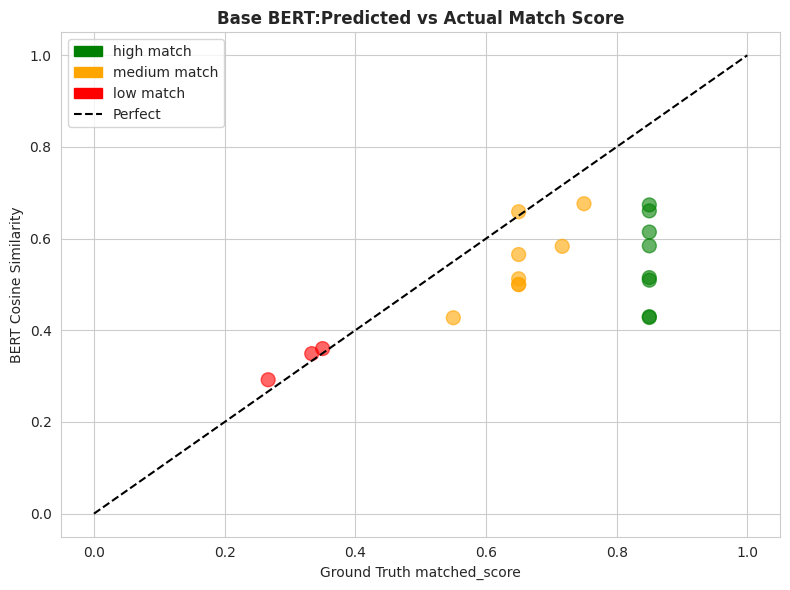

In [ ]:
plt.figure(figsize=(8,6))
colors=df['match_label'].map({'low match':'red','medium match':'orange','high match':'green'})
plt.scatter(df['matched_score'],df['bert_similarity'],c=colors,alpha=0.6, marker='o', s=100) # Increased marker size (s=100)
plt.plot([0,1],[0,1],'k--',label='Perfect prediction')
plt.xlabel('Ground Truth matched_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT:Predicted vs Actual Match Score', fontweight='bold')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green',label='high match'),
    Patch(color='orange',label='medium match'),
    Patch(color='red',label='low match'),
    plt.Line2D([0],[0],color='black',linestyle='--',label='Perfect')
])

plt.tight_layout()
plt.show()

In [ ]:
for label, color in [('low match','red'),
                     ('medium match','orange'),
                     ('high match','green')]:

    subset = df[df['match_label']==label]['bert_similarity']

    axes[0].hist(
        subset,
        bins=5,          # was 20
        alpha=0.6,
        color=color,
        label=label
    )

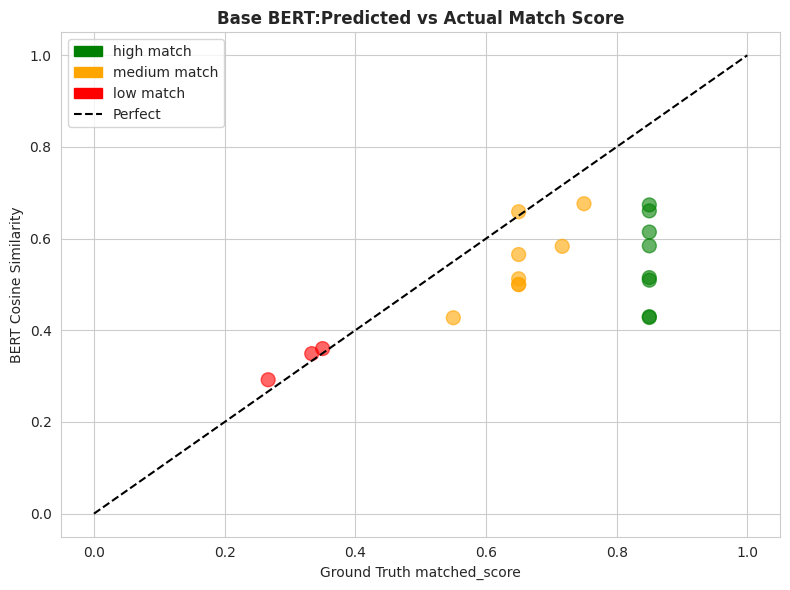

In [ ]:
plt.figure(figsize=(8,6))
colors=df['match_label'].map({'low match':'red','medium match':'orange','high match':'green'})
plt.scatter(df['matched_score'],df['bert_similarity'],c=colors,alpha=0.6, marker='o', s=100) # Increased marker size (s=100)
plt.plot([0,1],[0,1],'k--',label='Perfect prediction')
plt.xlabel('Ground Truth matched_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT:Predicted vs Actual Match Score', fontweight='bold')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green',label='high match'),
    Patch(color='orange',label='medium match'),
    Patch(color='red',label='low match'),
    plt.Line2D([0],[0],color='black',linestyle='--',label='Perfect')
])

plt.tight_layout()
plt.show()

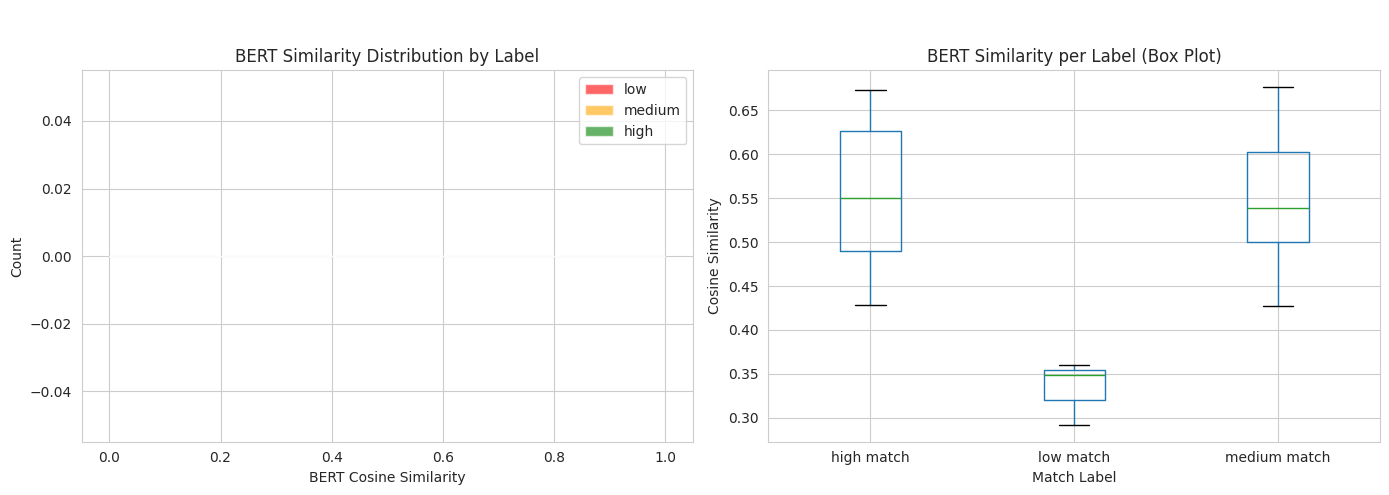


 Overlap between labels = base model struggles to separate high vs low matches
Goal of fine-tuning:push these distributions apart


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

for label,color in [('low','red'),('medium','orange'),('high','green')]:
  subset=df[df['match_label']==label]['bert_similarity']
  axes[0].hist(subset,bins=20,alpha=0.6,label=label,color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

df.boxplot(column='bert_similarity',by='match_label',positions=[0,1,2],ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')
plt.suptitle(' ')

plt.tight_layout()
plt.show()

print("\n Overlap between labels = base model struggles to separate high vs low matches")
print("Goal of fine-tuning:push these distributions apart")

In [ ]:
import pickle
with open('resume_embeddings.pkl','wb') as f:
  pickle.dump({
      'resume_embeddings':resume_embeddings,
      'jd_embeddings':jd_embeddings,
      'match_scores':df['matched_score'].tolist(),
      'match_labels':df['match_label'].tolist(),
  },f)

  print("Saved:resume_embeddings.pkl")
  print(f"resume_embeddings:{resume_embeddings.shape}")
  print(f"jd_embeddings:{jd_embeddings.shape}")
  print()
  print("These will be loaded for fine-tuning.")


Saved:resume_embeddings.pkl
resume_embeddings:(19, 768)
jd_embeddings:(19, 768)

These will be loaded for fine-tuning.
